In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ','.join(map(str, [1]))
print('using GPU %s' % ','.join(map(str, [1])))

import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from thop import profile, clever_format
from torch.optim.lr_scheduler import SequentialLR, StepLR

import csv
import time
import json
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
plt.rc('font',family='Times New Roman') 

from option import opt
from loadData import data_pipe, data_reader
from loadData.split_data import HyperX2
from loadData.dataAugmentation import DataAugmentationDINO2

from utils import util, trainer, tester, infoNCE, CELoss, visulization
from models import resNet2, heads, vision_transformer, automaticWeightedLoss
from models.MS2CANet import pymodel

using GPU 1


In [2]:
args = opt.get_args()
# args.dataset_name = "Houston_2018"
args.dataset_name = "Houston_2013"
# args.dataset_name ="Berlin"

args.backbone = "resNet"
# args.backbone = "dino"
# args.backbone = "MS2CANet"

args.awl = True
args.lambda_contra = 0.1
args.lambda_super = 1

args.patch_size = 13
args.randomCrop = 11
args.pca = True
args.components = 15

args.schedule = True
args.step_size = 30
args.gamma = 0.7


# elif args.backbone == "MS2CANet":
# 	args.patch_size = 11
# 	args.randomCrop = 11
# 	args.batch_size = 64
# 	args.learning_rate = 0.001
# 	args.pca = True
# 	args.components = 20
# 	args.schedule = True
# 	args.step_size = 5
# 	args.gamma = 0.3

pca is used


<Figure size 1200x800 with 0 Axes>

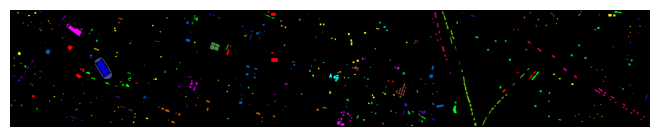

print_data_info : ---->
class 1 	 178 	 20 	 1053
class 2 	 171 	 19 	 1064
class 3 	 173 	 19 	 505
class 4 	 169 	 19 	 1056
class 5 	 167 	 19 	 1056
class 6 	 164 	 18 	 143
class 7 	 176 	 20 	 1072
class 8 	 172 	 19 	 1053
class 9 	 174 	 19 	 1059
class 10 	 172 	 19 	 1036
class 11 	 163 	 18 	 1054
class 12 	 173 	 19 	 1041
class 13 	 166 	 18 	 285
class 14 	 163 	 18 	 247
class 15 	 168 	 19 	 473
total     	 2549 	 283 	 12197
img1 (363, 1919, 15) img2 (363, 1919, 1) train_gt (363, 1919) val_gt (363, 1919) test_gt (363, 1919) data_gt (363, 1919)
15 (363, 1919) 2549


In [3]:
# data_pipe.set_deterministic(seed = 666)
args.print_data_info = True
args.show_gt = True
args.train_ratio = 0.9

# create dataloader
img1, img2, train_gt, val_gt, test_gt, data_gt = data_pipe.get_data(args)
print("img1", img1.shape, \
	  "img2", img2.shape, \
	  "train_gt", train_gt.shape, \
	  "val_gt", val_gt.shape, \
	  "test_gt", test_gt.shape, \
	  "data_gt", data_gt.shape)


height, wigth, data1_bands = img1.shape
height, wigth, data2_bands = img2.shape
transform = DataAugmentationDINO2(args)

args.remove_zero_labels = True
contrastive_dataset = HyperX2(img1, img2, data_gt, transform=transform, 
					   patch_size=args.patch_size, remove_zero_labels=args.remove_zero_labels)


args.remove_zero_labels = True
train_dataset = HyperX2(img1, img2, train_gt, transform=None, 
						patch_size=args.patch_size, remove_zero_labels=args.remove_zero_labels)
val_dataset = HyperX2(img1, img2, val_gt, transform=None, 
					  patch_size=args.patch_size, remove_zero_labels=args.remove_zero_labels)
test_dataset = HyperX2(img1, img2, test_gt, transform=None, 
					  patch_size=args.patch_size, remove_zero_labels=args.remove_zero_labels)

contrastive_loader = DataLoader(contrastive_dataset, batch_size=args.batch_size, shuffle=True, drop_last=True)
train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False)

class_num = np.max(train_gt)
print(class_num, train_gt.shape, len(train_loader.dataset))

In [4]:
for x11, x12, x21, x22, y in contrastive_loader:
    print("x11.shape, x12.shape", x11.shape, x12.shape, len(x11))
    print("x21.shape, x22.shape", x21.shape, x22.shape, len(x21))
    break

for x11, x21, y in train_loader:
    print("x11.shape", x11.shape)
    print("x21.shape", x21.shape)
    break

x11.shape, x12.shape torch.Size([512, 15, 11, 11]) torch.Size([512, 15, 11, 11]) 512
x21.shape, x22.shape torch.Size([512, 1, 11, 11]) torch.Size([512, 1, 11, 11]) 512
x11.shape torch.Size([512, 15, 13, 13])
x21.shape torch.Size([512, 1, 13, 13])


In [5]:
# 加载已有权重路径
# args.result_dir = "/home/leo/Multimodal_Classification/KnowCLPlus/results/04-01-17-21-cnn_D3M"

args.result_dir = os.path.join("/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result",
                    datetime.now().strftime("%m-%d-%H-%M-" + args.backbone + "_D3"))
print(args.result_dir)

if not os.path.exists(args.result_dir):
    os.mkdir(args.result_dir)
with open(args.result_dir + '/args.json', 'w') as fid:
    json.dump(args.__dict__, fid, indent=2)

/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result/07-31-21-43-resNet_D3


# model

In [6]:
if args.backbone == "resNet":
    encoder = resNet2.ResNet(data1_bands, data2_bands).to(args.device)
    args.feature_dim = 512
    # args.feature_dim = 2048
    super_head = heads.linearHead(args.feature_dim, class_num=class_num).to(args.device)
    contra_head = heads.DINOHead(args.feature_dim).to(args.device)
    # net = encoder.to(args.device)
    awl = automaticWeightedLoss.AutomaticWeightedLoss(2).to(args.device)
    params = list(super_head.parameters()) + list(contra_head.parameters()) + list(encoder.parameters())
    
elif args.backbone == "MS2CANet":
    FM = 64
    args.feature_dim = 256
    para_tune = False
    if args.dataset_name == "Houston_2013":
        para_tune = True                # para_tune 这个参数对于 Houston 的提升有两个点！！
    encoder = pymodel.pyCNN(FM=FM, NC=args.components, para_tune=para_tune).to(args.device)
    super_head = heads.MS2_head(args.feature_dim, class_num=class_num).to(args.device)
    contra_head = heads.DINOHead(args.feature_dim).to(args.device)
    # net = util.MultiCropWrapper_MS2(encoder).to(args.device)
    awl = automaticWeightedLoss.AutomaticWeightedLoss(2).to(args.device)
    params = list(super_head.parameters()) + list(encoder.parameters()) + list(encoder.parameters())
# super_head = heads.FDGC_head(args.feature_dim, class_num=class_num).to(args.device)

optimizer = optim.Adam(params, lr=args.learning_rate, weight_decay=args.weight_decay, amsgrad=True)
criterion1 = torch.nn.CrossEntropyLoss()
criterion2 = CELoss.LabelSmoothSoftmaxCEV1(lb_smooth=0.1)
criterion3 = CELoss.SoftTargetCrossEntropy()
criterion4 = infoNCE.InfoNCE()
criterion5 = infoNCE.NT_xent_loss_W_EN()

warmup = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda e: min(1.0, e / 5.0))
decay = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args.step_size, gamma=args.gamma)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup, decay], milestones=[5])

In [7]:
# flops, params = profile(net, 
#                         inputs=(torch.randn(2, 
#                                         args.components, 
#                                         args.patch_size, 
#                                         args.patch_size).cuda(),))
# flops, params = clever_format([flops, params])
# print('# Model Params: {} FLOPs: {}'.format(params, flops))

# # contra_head
# flops, params = profile(contra_head, inputs=(torch.randn(1, args.feature_dim).cuda(),))
# flops, params = clever_format([flops, params])
# print('# Model Params: {} FLOPs: {}'.format(params, flops))

# # super_head
# flops, params = profile(super_head, inputs=(torch.randn(1, args.feature_dim).cuda(),))
# flops, params = clever_format([flops, params])
# print('# Model Params: {} FLOPs: {}'.format(params, flops))

# 训练前加载权重

In [8]:
# args.resume = os.path.join(args.result_dir, "joint_oa_model.pth")
if args.resume != '':
    checkpoint = torch.load(args.resume)
    encoder.load_state_dict(checkpoint['model'], strict=False)
    epoch_start = checkpoint['epoch'] + 1
    print('Loaded from: {}'.format(args.resume))
else:
    epoch_start = 0

# 训练

In [9]:
best_loss = 999
best_acc = 0
train_losses = []
test_losses = []
loss_contras = []
loss_supers = []
train_accuracies = []
test_accuracies = []

start_time = time.time()
for epoch in range(epoch_start, args.epochs):
###################################################################->>>>>>>>>
    if args.backbone == "resNet":
        train_loss, loss_contra, loss_super, linear_tra \
                    = trainer.trainer(encoder, contra_head, super_head, awl, criterion2, criterion4, \
                                         criterion5, train_loader, contrastive_loader, optimizer, args)
        if epoch % args.log_interval == 0:
            test_loss, test_preds, targets, linear_tes = \
                tester.tester(encoder, super_head, criterion2, val_loader, args)


    elif args.backbone == "MS2CANet":
        train_loss, loss_contra, loss_super, linear_tra, train_time \
                    = trainer.train_ms2ca2(encoder, contra_head, super_head, awl, criterion1, criterion2, \
                                    train_loader, contrastive_loader, test_loader, optimizer, args)
        if epoch % args.log_interval == 0:
            test_loss, test_preds, targets, linear_tes = \
                tester.linear_test_ms2ca2(encoder, super_head, criterion2, val_loader, args)
            
    else:
        raise NotImplementedError("Backbone not implemented: {}".format(args.backbone))
            
    train_time = time.time() - start_time
    print('Train Epoch: [{}/{}] Loss: {:.4f} loss_contra: {:.4f} loss_super: {:.4f} TRA: {:.4f} TEA: {:.4f} TIME: {:.4f}'.format(\
                            epoch, args.epochs, 
                            train_loss, 
                            loss_contra,
                            loss_super, 
                            linear_tra, 
                            linear_tes, 
                            train_time
                            ))

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    loss_contras.append(loss_contra)
    loss_supers.append(loss_super)
    train_accuracies.append(linear_tra)
    test_accuracies.append(linear_tes)
    scheduler.step()
        
###################################################################<<<<<<<<<<<<-
    with open(os.path.join(args.result_dir, "log.csv"), 'a+', encoding='gbk') as f:
        row=[["epoch", epoch, 
            "loss", train_loss, 
            "loss_contra", loss_contra,
            "loss_super", loss_super,
            "linear_tracc", linear_tra,
            "linear_teacc", linear_tes,
            "train_time", round(train_time, 2),
            '\n',
            ]]
        write=csv.writer(f)
        for i in range(len(row)):
            write.writerow(row[i])

    best_loss, best_acc = util.save_weights(train_loss, test_loss, best_loss, best_acc,
                      linear_tes, epoch, encoder, super_head, contra_head, optimizer, args)
###################################################################<<<<<<<<<<<<-
total_trian_time = time.time() - start_time

torch.save({
        "epoch": epoch,
        "model": encoder.state_dict(),
        "super_head": super_head.state_dict(),
        "contra_head": contra_head.state_dict(),
        "optimizer": optimizer.state_dict()}, 
os.path.join(args.result_dir, "model_last.pth"))

Train Epoch: [0/50] Loss: 3.9440 loss_contra: 2.2282 loss_super: 2.8871 TRA: 5.7670 TEA: 8.4806 TIME: 1.6777
Train Epoch: [1/50] Loss: 3.1481 loss_contra: 2.1056 loss_super: 1.4179 TRA: 56.8066 TEA: 54.4170 TIME: 3.2329
Train Epoch: [2/50] Loss: 2.7974 loss_contra: 2.0278 loss_super: 0.7944 TRA: 93.0561 TEA: 63.2509 TIME: 4.8449
Train Epoch: [3/50] Loss: 2.6699 loss_contra: 1.9380 loss_super: 0.6291 TRA: 99.2546 TEA: 82.6855 TIME: 6.4550
Train Epoch: [4/50] Loss: 2.6282 loss_contra: 1.8754 loss_super: 0.6085 TRA: 99.9215 TEA: 86.9258 TIME: 8.0264


/home/icclab/miniconda3/envs/leo/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:198: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Train Epoch: [5/50] Loss: 2.6072 loss_contra: 1.8459 loss_super: 0.5958 TRA: 100.0000 TEA: 87.9859 TIME: 9.7193
Train Epoch: [6/50] Loss: 2.5909 loss_contra: 1.8150 loss_super: 0.5942 TRA: 100.0000 TEA: 85.8657 TIME: 11.3028
Train Epoch: [7/50] Loss: 2.5734 loss_contra: 1.7875 loss_super: 0.5867 TRA: 100.0000 TEA: 87.6325 TIME: 12.4828
Train Epoch: [8/50] Loss: 2.5663 loss_contra: 1.7711 loss_super: 0.5890 TRA: 100.0000 TEA: 86.5724 TIME: 14.0592
Train Epoch: [9/50] Loss: 2.5526 loss_contra: 1.7443 loss_super: 0.5882 TRA: 100.0000 TEA: 92.9329 TIME: 15.6465
Train Epoch: [10/50] Loss: 2.5492 loss_contra: 1.7400 loss_super: 0.5858 TRA: 100.0000 TEA: 88.3392 TIME: 17.2103
Train Epoch: [11/50] Loss: 2.5455 loss_contra: 1.7347 loss_super: 0.5837 TRA: 100.0000 TEA: 91.5194 TIME: 18.4051
Train Epoch: [12/50] Loss: 2.5299 loss_contra: 1.7055 loss_super: 0.5818 TRA: 100.0000 TEA: 96.1131 TIME: 19.9744
Train Epoch: [13/50] Loss: 2.5341 loss_contra: 1.7116 loss_super: 0.5841 TRA: 100.0000 TEA: 95

# 保存最优结果

In [10]:
args.resume = os.path.join(args.result_dir, "test_loss.pth")
if args.resume != '':
    checkpoint = torch.load(args.resume)
    encoder.load_state_dict(checkpoint['model'], strict=False)
    super_head.load_state_dict(checkpoint['super_head'], strict=False)
    contra_head.load_state_dict(checkpoint['contra_head'], strict=False)
    epoch = checkpoint['epoch'] + 1
    print('Loaded from: {} epoch {}'.format(args.resume, epoch))
else:
    epoch_start = 0


# linear 精度
start_time = time.time()
if args.backbone == "resNet":
        test_loss, test_preds, targets, test_accuracy = \
    tester.tester(encoder, super_head, criterion2, test_loader, args)
        
elif args.backbone == "MS2CANet":
    test_loss, test_preds, targets, test_accuracy = \
        tester.linear_test_ms2ca2(encoder, super_head, criterion2, test_loader, args)
Linear_time = time.time() - start_time

classification, kappa = tester.get_results(test_preds, targets)
print("classification", classification)
print("kappa", kappa)


with open(os.path.join(args.result_dir, "log_final.csv"), 'a+', encoding='gbk') as f:
    row=[["epoch", epoch, 
        "\nclassification\n", classification,
        "\nkappa", kappa,
        "\nLinear_time", np.round(Linear_time, 2),
        "\nTrian_time", round(total_trian_time, 2)
        ]]
    write=csv.writer(f)
    for i in range(len(row)):
        write.writerow(row[i])

Loaded from: /home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result/07-31-21-43-resNet_D3/test_loss.pth epoch 37
classification               precision    recall  f1-score   support

           0     0.9904    0.7863    0.8767      1053
           1     0.8331    0.9615    0.8927      1064
           2     0.9978    0.8911    0.9414       505
           3     0.9845    0.9593    0.9717      1056
           4     1.0000    0.9924    0.9962      1056
           5     0.7829    0.9580    0.8616       143
           6     0.9197    0.9832    0.9504      1072
           7     0.8241    0.9696    0.8909      1053
           8     0.9659    0.9103    0.9373      1059
           9     0.8271    0.7297    0.7754      1036
          10     0.9857    0.9127    0.9478      1054
          11     0.9619    0.9702    0.9660      1041
          12     0.8343    0.9719    0.8979       285
          13     1.0000    1.0000    1.0000       247
          14     0.8958    1.0000    0.9451       

# 绘图

In [ ]:
args.resume = os.path.join(args.result_dir, "test_loss.pth")
if args.resume != '':
    checkpoint = torch.load(args.resume)
    encoder.load_state_dict(checkpoint['model'], strict=False)
    epoch_start = checkpoint['epoch'] + 1
    print('Loaded from: {}'.format(args.resume))
else:
    epoch_start = 0


_, _, groundTruth = data_reader.load_data(args.dataset_name, path_data=args.path_data, type_data="GT")

args.show_gt = False
args.remove_zero_labels = False
args.print_data_info = False
args.train_ratio = 1
img1, img2, train_gt, val_gt, test_gt, data_gt = data_pipe.get_data(args)

# create dataloader
data_dataset = HyperX2(img1, img2, data_gt, transform=None, 
                       patch_size=args.patch_size, 
                        remove_zero_labels=args.remove_zero_labels)
data_loader = torch.utils.data.DataLoader(data_dataset, batch_size=args.batch_size, \
                                           shuffle=False, drop_last=False)

visulization.visulization(encoder, super_head, data_loader, groundTruth, args)

Loaded from: /home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result/07-31-21-43-resNet_D3/test_loss.pth
pca is used


# 画 loss 曲线

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

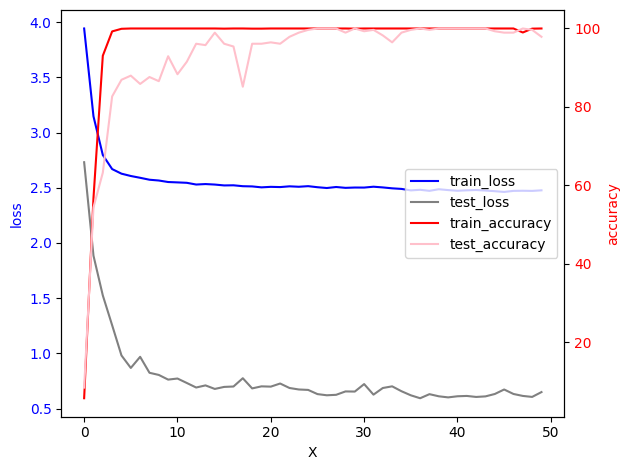

In [12]:
args.plot_loss_curve = True
if args.plot_loss_curve:
    # fig = plt.figure()
    fig, ax1 = plt.subplots()

    # 绘制第一个数据，使用左侧y轴
    ax1.plot(range(args.epochs), train_losses, 'blue', label="train_loss")
    ax1.plot(range(args.epochs), test_losses, 'gray', label="test_loss")
    ax1.set_xlabel('X')
    ax1.set_ylabel('loss', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    # 创建第二个坐标轴，共享x轴但y轴在右侧
    ax2 = ax1.twinx()
    ax2.plot(range(args.epochs), train_accuracies, 'red', label="train_accuracy")
    ax2.plot(range(args.epochs), test_accuracies, 'pink', label="test_accuracy")
    ax2.set_ylabel('accuracy', color='r')
    ax2.tick_params(axis='y', labelcolor='r')


    fig.tight_layout()  # 自动调整布局以避免重叠

    # # 获取两个坐标轴上的线条和标签
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc=5)
    # plt.legend(['train_losses', 'train_accuracies', 'test_accuracies'], loc='upper right')
    # plt.xlabel('number of training examples seen')
    # plt.ylabel('Accuracy')
    plt.savefig(os.path.join(args.result_dir, "learning_curve.png"), dpi=200)

# TSNE

In [13]:
# with torch.no_grad():
#     for idx_o, (data, _, target) in enumerate(test_loader):
#         target = target - 1
#         data = data.to(args.device)
        
#         output = super_head(net(data))
#         target = target.to(args.device)

#         for idx, _ in enumerate(output.cpu().numpy()):
#             # print(output.cpu().numpy().shape)
#             if idx == 0 and idx_o == 0:
#                 list_output = output.cpu().numpy()[idx]
#                 list_target = target.cpu().numpy()[idx]
#             # print(list_output.shape, list_target.shape)

#             if idx < 100:
#                 list_output = np.vstack((list_output, output.cpu().numpy()[idx]))
#                 list_target = np.append(list_target, target.cpu().numpy()[idx])

In [14]:
# tsne = TSNE()

# out = tsne.fit_transform(list_output)
# fig, ax = plt.subplots()
# ax.set_axis_off()
# ax.xaxis.set_visible(False)
# ax.yaxis.set_visible(False)
# # fig.set_size_inches(label.shape[1] * scale / dpi, label.shape[0] * scale / dpi)
# plt.gca().xaxis.set_major_locator(plt.NullLocator())
# plt.gca().yaxis.set_major_locator(plt.NullLocator())
# plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)

# label = ["Broccoli-weeds-1","Broccoli-weeds-2","Fallow","Fallow-rough-plow",
#          "Fallow-smooth","Stubble","Celery","Grapes-untrained",
#          "Soil-senesced-develop","Corn-weeds","Lettuce-4wk","Lettuce-5wk",
#          "Lettuce-6wk","Lettuce-7wk","Vinyard-untrained",
#          "Vinyard-vertical-trellis"]
# for i in range(class_num):
#     indices = list_target  == i
#     x, y = out[indices].T
#     # plt.scatter(x, y, s=5, label=label[i])
#     plt.scatter(x, y, s=5, label=str(i+1))
# plt.legend(loc=2,bbox_to_anchor=(1.05,1.0),borderaxespad = 0., fontsize=12)
# plt.savefig(args.result_dir  + '/tsneFull' + '.png', dpi=400, bbox_inches="tight")